# Tutorial 3 — Optimized MoCo Pretraining with YOLO26 Segmentation

**Course:** CSE445 — Computer Vision  
**Instructor:** Dr Mohammad Rifat Ahmmad Rashid  

**Dataset:** Brain Tumor Image Dataset — Semantic Segmentation  
**Kaggle source:** `pkdarabi/brain-tumor-image-dataset-semantic-segmentation`

**Pipeline:** MRI images without labels → MoCo pretraining of the YOLO26 feature extractor → supervised YOLO26 segmentation fine-tuning → mask evaluation and interpretation.

This implementation includes nested progress bars, throughput reporting, mixed precision, pinned-memory loading, persistent workers, prefetching, gradient accumulation, optional `channels_last`, optional `torch.compile`, a momentum key encoder, and a circular negative-key queue.


## How the complete method works

The notebook has two connected learning stages.

### Stage A — Momentum Contrast pretraining

For each MRI image $x$, two stochastic transformations produce:

$$
x_q=t_q(x), \qquad x_k=t_k(x).
$$

The first view is processed by the **query encoder**:

$$
q=f_q(x_q).
$$

The second view is processed by the **key encoder**:

$$
k=f_k(x_k).
$$

Only the query encoder is updated directly by backpropagation. The key encoder is updated using an exponential moving average:

$$
\theta_k \leftarrow m\theta_k+(1-m)\theta_q,
$$

where $m$ is the momentum coefficient.

The query and its matching key form a positive pair. A queue stores keys from earlier mini-batches and supplies many negative examples. The MoCo objective is:

$$
\ell
=
-\log
\frac{\exp(q^\top k^+/\tau)}
{\exp(q^\top k^+/\tau)+
\sum_{i=1}^{K}\exp(q^\top k_i^-/\tau)}.
$$

Here, $k^+$ is the matching key, $k_i^-$ are negative keys, $K$ is the queue length, and $\tau$ is the temperature.

After each mini-batch:

1. update the key encoder by momentum;
2. add the newest key vectors to the queue;
3. remove the oldest queue entries.

### Stage B — Supervised YOLO26 segmentation

After MoCo pretraining:

1. discard the momentum key encoder;
2. discard both projection heads and the queue;
3. retain the query encoder's YOLO26 backbone and neck;
4. train the YOLO26 segmentation head using tumor polygons;
5. fine-tune the complete model end to end.

### Why MoCo is useful here

Medical-image experiments often use small mini-batches because of GPU-memory limits. SimCLR normally benefits from large batches, while MoCo obtains many negatives from its queue. This makes MoCo suitable for single-GPU MRI representation learning.

```text
MRI image
   │
   ├── query augmentation ──> query YOLO26 encoder ──> q
   │                                                  │
   │                                                  ├── positive key
   │                                                  ├── queue negatives
   │                                                  └── contrastive loss
   │
   └── key augmentation ────> momentum YOLO26 encoder ──> k
                                                      │
                                                      └── update queue

query encoder weights
        │
        └──> YOLO26 segmentation fine-tuning with tumor polygons
```

> MoCo does not directly learn tumor masks during pretraining. It first learns transferable MRI representations; supervised fine-tuning then converts those representations into a segmentation model.


## Learning objectives

Students will learn to:

1. explain the query encoder, momentum key encoder, and negative queue;
2. derive the MoCo logits and cross-entropy objective;
3. implement momentum updates without gradients through the key encoder;
4. maintain a circular queue of normalized negative keys;
5. pretrain the actual YOLO26 feature extractor;
6. retain the query encoder for YOLO26 segmentation fine-tuning;
7. compare MoCo with random initialization and SimCLR.


In [1]:
# Cell 1 — Install dependencies
!pip install -q -U ultralytics lxml scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 103.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 109.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.


In [2]:
# Cell 2 — Imports, configuration, reproducibility, and device
import copy
import os
import random
import shutil
import warnings
import json
from contextlib import nullcontext
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
from IPython.display import display
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split

from ultralytics import YOLO
import ultralytics

warnings.filterwarnings("ignore", category=UserWarning)


@dataclass
class CFG:
    seed: int = 42
    num_workers: int = 2
    prefetch_factor: int = 2
    persistent_workers: bool = True

    data_root: str = "/kaggle/input/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation"
    working_root: str = "/kaggle/working/cse445_moco_yolo26"
    prepared_dataset_name: str = "brain_tumor_yolo_seg"

    yolo_model: str = "yolo26n-seg.yaml"

    ssl_image_size: int = 320
    ssl_batch_size: int = 16
    ssl_epochs: int = 5
    ssl_learning_rate: float = 3e-4
    ssl_weight_decay: float = 1e-4
    gradient_accumulation_steps: int = 1
    use_channels_last: bool = True
    use_torch_compile: bool = False
    temperature: float = 0.20
    projection_hidden_dim: int = 1024
    projection_dim: int = 128
    momentum: float = 0.999
    queue_size: int = 4096

    segmentation_image_size: int = 640
    segmentation_batch_size: int = 8
    segmentation_epochs: int = 10
    segmentation_patience: int = 10

    validation_fraction: float = 0.15
    test_fraction: float = 0.15
    debug_subset: Optional[int] = None
    tsne_max_samples: int = 300


cfg = CFG()

random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = device.type == "cuda"

if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")

DATA_ROOT = Path(cfg.data_root)
WORKING_ROOT = Path(cfg.working_root)
PREPARED_ROOT = WORKING_ROOT / cfg.prepared_dataset_name
SSL_OUTPUT_DIR = WORKING_ROOT / "ssl_outputs"
SEGMENTATION_PROJECT_DIR = WORKING_ROOT / "segmentation_runs"

for directory in [WORKING_ROOT, SSL_OUTPUT_DIR, SEGMENTATION_PROJECT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

if hasattr(torch, "amp") and hasattr(torch.amp, "GradScaler"):
    SCALER = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
else:
    SCALER = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

def amp_context():
    if AMP_ENABLED:
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()

print("Ultralytics:", ultralytics.__version__)
print("PyTorch:", torch.__version__)
print("Device:", device)
display(pd.DataFrame([asdict(cfg)]).T.rename(columns={0: "value"}))

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics: 8.4.95
PyTorch: 2.10.0+cu128
Device: cuda


,value
seed,42
num_workers,2
prefetch_factor,2
persistent_workers,True
data_root,/kaggle/input/datasets/pkdarabi/brain-tumor-im...
working_root,/kaggle/working/cse445_moco_yolo26
prepared_dataset_name,brain_tumor_yolo_seg
yolo_model,yolo26n-seg.yaml
ssl_image_size,320
ssl_batch_size,16


## 1. Prepare the Kaggle brain-tumor segmentation dataset

The Kaggle dataset is commonly exported in a Roboflow-style COCO layout:

```text
dataset-root/
├── train/
│   ├── _annotations.coco.json
│   └── image files
├── valid/
│   ├── _annotations.coco.json
│   └── image files
└── test/
    ├── _annotations.coco.json
    └── image files
```

Each COCO annotation contains one or more tumor polygons. Ultralytics segmentation labels use one row per polygon:

$$
c,\quad x_1/W,\quad y_1/H,\quad x_2/W,\quad y_2/H,\ldots,x_n/W,\quad y_n/H.
$$

The conversion cells recursively locate the COCO annotation files, preserve the supplied train/validation/test split, normalize polygon coordinates, remove invalid polygons, and create an Ultralytics-compatible `data.yaml`. The original Kaggle input is never modified.


In [3]:
# Cell 3 — Discover and parse COCO segmentation annotations
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset root was not found: {DATA_ROOT}\n"
        "Attach the Kaggle dataset or update CFG.data_root."
    )

annotation_files = sorted(DATA_ROOT.rglob("*annotations*.json"))
if not annotation_files:
    annotation_files = sorted(DATA_ROOT.rglob("*.json"))

if not annotation_files:
    raise FileNotFoundError(
        f"No COCO JSON annotation file was found under {DATA_ROOT}."
    )


def infer_split_name(annotation_path):
    text = " ".join(part.lower() for part in annotation_path.parts)
    if "train" in text:
        return "train"
    if "valid" in text or "val" in text:
        return "val"
    if "test" in text:
        return "test"
    return None


def locate_coco_image(annotation_path, file_name):
    candidates = [
        annotation_path.parent / file_name,
        annotation_path.parent / Path(file_name).name,
        DATA_ROOT / file_name,
        DATA_ROOT / Path(file_name).name,
    ]
    for candidate in candidates:
        if candidate.exists() and candidate.is_file():
            return candidate

    matches = list(DATA_ROOT.rglob(Path(file_name).name))
    return matches[0] if matches else None


def polygon_area(flat_polygon):
    points = np.asarray(flat_polygon, dtype=np.float64).reshape(-1, 2)
    x = points[:, 0]
    y = points[:, 1]
    return 0.5 * abs(
        np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1))
    )


all_records = []
category_id_to_name = {}
failed_items = []

for annotation_path in annotation_files:
    split_name = infer_split_name(annotation_path)
    if split_name is None:
        continue

    try:
        coco = json.loads(annotation_path.read_text(encoding="utf-8"))
    except Exception as error:
        failed_items.append((str(annotation_path), str(error)))
        continue

    local_categories = {
        int(category["id"]): str(category["name"])
        for category in coco.get("categories", [])
    }
    category_id_to_name.update(local_categories)

    annotations_by_image = {}
    for annotation in coco.get("annotations", []):
        annotations_by_image.setdefault(int(annotation["image_id"]), []).append(annotation)

    for image_info in coco.get("images", []):
        image_id = int(image_info["id"])
        image_path = locate_coco_image(annotation_path, image_info["file_name"])
        if image_path is None:
            failed_items.append((image_info["file_name"], "image not found"))
            continue

        width = int(image_info.get("width", 0))
        height = int(image_info.get("height", 0))
        if width <= 0 or height <= 0:
            with Image.open(image_path) as image:
                width, height = image.size

        polygon_instances = []
        for annotation in annotations_by_image.get(image_id, []):
            category_id = int(annotation["category_id"])
            segmentation = annotation.get("segmentation", [])

            # This notebook expects polygon-style COCO annotations. Compressed
            # RLE masks require pycocotools and contour extraction.
            if not isinstance(segmentation, list):
                continue

            for polygon in segmentation:
                if not isinstance(polygon, list) or len(polygon) < 6:
                    continue
                if len(polygon) % 2 != 0:
                    polygon = polygon[:-1]
                if len(polygon) < 6 or polygon_area(polygon) <= 1.0:
                    continue

                polygon_instances.append({
                    "category_id": category_id,
                    "category_name": local_categories.get(category_id, str(category_id)),
                    "polygon": polygon,
                })

        all_records.append({
            "split": split_name,
            "image_path": str(image_path),
            "width": width,
            "height": height,
            "polygons": polygon_instances,
            "number_of_masks": len(polygon_instances),
        })

dataset_frame = pd.DataFrame(all_records)
if dataset_frame.empty:
    raise RuntimeError("No valid COCO image records were found.")

if cfg.debug_subset is not None:
    sampled_parts = []
    for split_name, split_frame in dataset_frame.groupby("split"):
        sampled_parts.append(
            split_frame.sample(
                min(cfg.debug_subset, len(split_frame)),
                random_state=cfg.seed,
            )
        )
    dataset_frame = pd.concat(sampled_parts, ignore_index=True)

category_names = sorted(set(category_id_to_name.values()))
category_name_to_yolo_id = {
    category_name: index
    for index, category_name in enumerate(category_names)
}
class_names = category_names

print(f"Annotation files: {len(annotation_files)}")
print(f"Valid images: {len(dataset_frame):,}")
print(f"Skipped items: {len(failed_items):,}")
print("Split counts:")
display(dataset_frame["split"].value_counts().rename_axis("split").to_frame("images"))
print("Classes:", class_names)
display(dataset_frame[["split", "image_path", "width", "height", "number_of_masks"]].head())


Annotation files: 3
Valid images: 2,146
Skipped items: 0
Split counts:


,images
split,
train,1502
val,429
test,215


Classes: ['0', '1', 'Tumor']


,split,image_path,width,height,number_of_masks
0,test,/kaggle/input/datasets/pkdarabi/brain-tumor-im...,640,640,1
1,test,/kaggle/input/datasets/pkdarabi/brain-tumor-im...,640,640,1
2,test,/kaggle/input/datasets/pkdarabi/brain-tumor-im...,640,640,1
3,test,/kaggle/input/datasets/pkdarabi/brain-tumor-im...,640,640,1
4,test,/kaggle/input/datasets/pkdarabi/brain-tumor-im...,640,640,1


In [4]:
# Cell 4 — Export Ultralytics polygon-segmentation labels
def polygon_to_yolo_line(instance, width, height):
    class_id = category_name_to_yolo_id[instance["category_name"]]
    coordinates = np.asarray(instance["polygon"], dtype=np.float64).reshape(-1, 2)

    coordinates[:, 0] = np.clip(coordinates[:, 0] / width, 0.0, 1.0)
    coordinates[:, 1] = np.clip(coordinates[:, 1] / height, 0.0, 1.0)

    flattened = coordinates.reshape(-1)
    if len(flattened) < 6:
        return None

    return f"{class_id} " + " ".join(f"{value:.6f}" for value in flattened)


split_frames = {
    split_name: split_frame.reset_index(drop=True)
    for split_name, split_frame in dataset_frame.groupby("split")
}

required_splits = {"train", "val", "test"}
missing_splits = required_splits - set(split_frames)
if missing_splits:
    raise RuntimeError(
        f"Missing expected dataset splits: {sorted(missing_splits)}. "
        "Check the Kaggle directory structure."
    )

if PREPARED_ROOT.exists():
    shutil.rmtree(PREPARED_ROOT)

for split_name in required_splits:
    (PREPARED_ROOT / "images" / split_name).mkdir(parents=True, exist_ok=True)
    (PREPARED_ROOT / "labels" / split_name).mkdir(parents=True, exist_ok=True)

manifest_rows = []

for split_name, frame in split_frames.items():
    for row_index, row in tqdm(
        frame.iterrows(),
        total=len(frame),
        desc=f"Exporting {split_name}",
        leave=False,
    ):
        source_image = Path(row["image_path"])
        destination_name = f"{row_index:06d}_{source_image.name}"
        destination_image = PREPARED_ROOT / "images" / split_name / destination_name
        destination_label = (
            PREPARED_ROOT
            / "labels"
            / split_name
            / f"{Path(destination_name).stem}.txt"
        )

        shutil.copy2(source_image, destination_image)

        label_lines = []
        for instance in row["polygons"]:
            line = polygon_to_yolo_line(
                instance,
                int(row["width"]),
                int(row["height"]),
            )
            if line is not None:
                label_lines.append(line)

        destination_label.write_text(
            "\n".join(label_lines),
            encoding="utf-8",
        )

        manifest_rows.append({
            "split": split_name,
            "image_path": str(destination_image),
            "label_path": str(destination_label),
            "number_of_masks": len(label_lines),
        })

manifest = pd.DataFrame(manifest_rows)
manifest.to_csv(PREPARED_ROOT / "manifest.csv", index=False)

data_yaml = PREPARED_ROOT / "data.yaml"
yaml_lines = [
    f"path: {PREPARED_ROOT}",
    "train: images/train",
    "val: images/val",
    "test: images/test",
    "names:",
]
yaml_lines.extend(
    f"  {class_id}: {class_name}"
    for class_name, class_id in category_name_to_yolo_id.items()
)
data_yaml.write_text("\n".join(yaml_lines), encoding="utf-8")

summary = manifest.groupby("split").agg(
    images=("image_path", "count"),
    masks=("number_of_masks", "sum"),
    mean_masks_per_image=("number_of_masks", "mean"),
)
display(summary.round(3))
print(data_yaml.read_text())


Exporting test:   0%|          | 0/215 [00:00<?, ?it/s]

Exporting train:   0%|          | 0/1502 [00:00<?, ?it/s]

Exporting val:   0%|          | 0/429 [00:00<?, ?it/s]

,images,masks,mean_masks_per_image
split,,,
test,215,215,1.0
train,1502,1502,1.0
val,429,429,1.0


path: /kaggle/working/cse445_moco_yolo26/brain_tumor_yolo_seg
train: images/train
val: images/val
test: images/test
names:
  0: 0
  1: 1
  2: Tumor


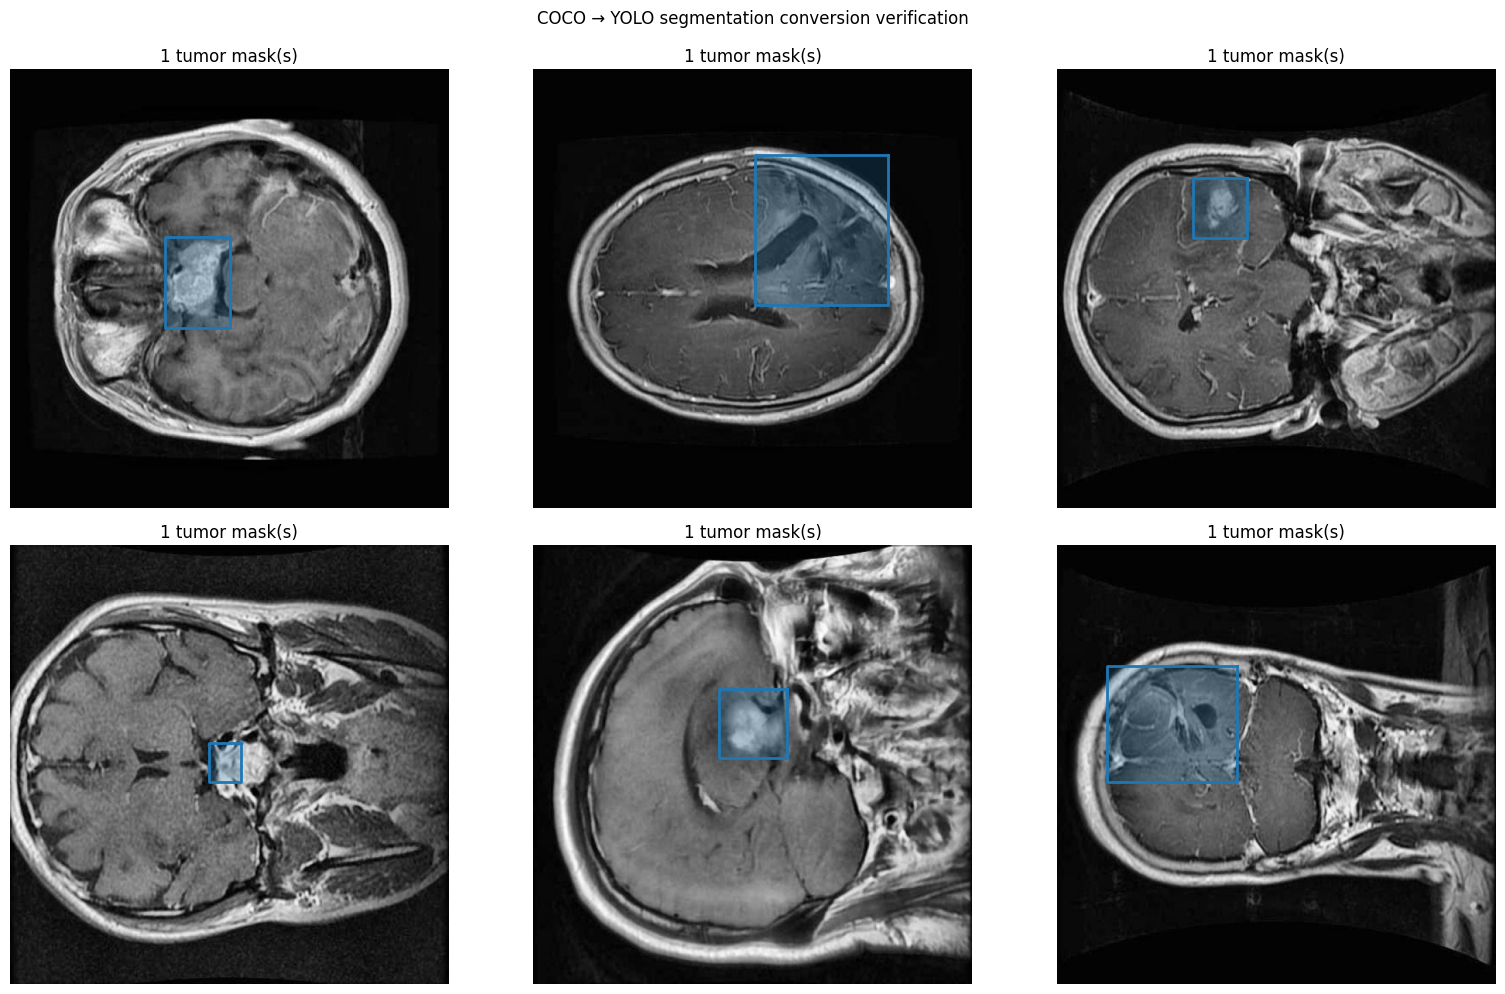

In [5]:
# Cell 5 — Visual verification of converted segmentation polygons
def read_yolo_segmentation_labels(label_path, image_width, image_height):
    instances = []
    for line in Path(label_path).read_text(encoding="utf-8").splitlines():
        parts = line.strip().split()
        if len(parts) < 7:
            continue

        class_id = int(parts[0])
        coordinates = np.asarray(parts[1:], dtype=np.float64).reshape(-1, 2)
        coordinates[:, 0] *= image_width
        coordinates[:, 1] *= image_height
        instances.append((class_id, coordinates))
    return instances


sample_rows = manifest[manifest["split"] == "train"].sample(
    min(6, (manifest["split"] == "train").sum()),
    random_state=cfg.seed,
)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = np.asarray(axes).reshape(-1)

for axis, (_, row) in zip(axes, sample_rows.iterrows()):
    image = Image.open(row["image_path"]).convert("RGB")
    instances = read_yolo_segmentation_labels(
        row["label_path"],
        *image.size,
    )

    axis.imshow(image)
    for class_id, polygon in instances:
        closed_polygon = np.vstack([polygon, polygon[0]])
        axis.plot(
            closed_polygon[:, 0],
            closed_polygon[:, 1],
            linewidth=2,
            label=class_names[class_id],
        )
        axis.fill(
            polygon[:, 0],
            polygon[:, 1],
            alpha=0.22,
        )

    axis.set_title(f"{len(instances)} tumor mask(s)")
    axis.axis("off")

for axis in axes[len(sample_rows):]:
    axis.axis("off")

plt.suptitle("COCO → YOLO segmentation conversion verification", y=0.99)
plt.tight_layout()
plt.show()


## 2. Stage A — MoCo pretraining

Two independently augmented views of each MRI image are encoded by two related networks.

The positive similarity is:

$$
l^+=q^\top k^+.
$$

The negative similarities are:

$$
l_i^-=q^\top k_i^-.
$$

The complete logits are divided by temperature $\tau$ and optimized using cross-entropy, with the positive key assigned to class index $0$.

Tumor masks and class labels are not used during this stage.


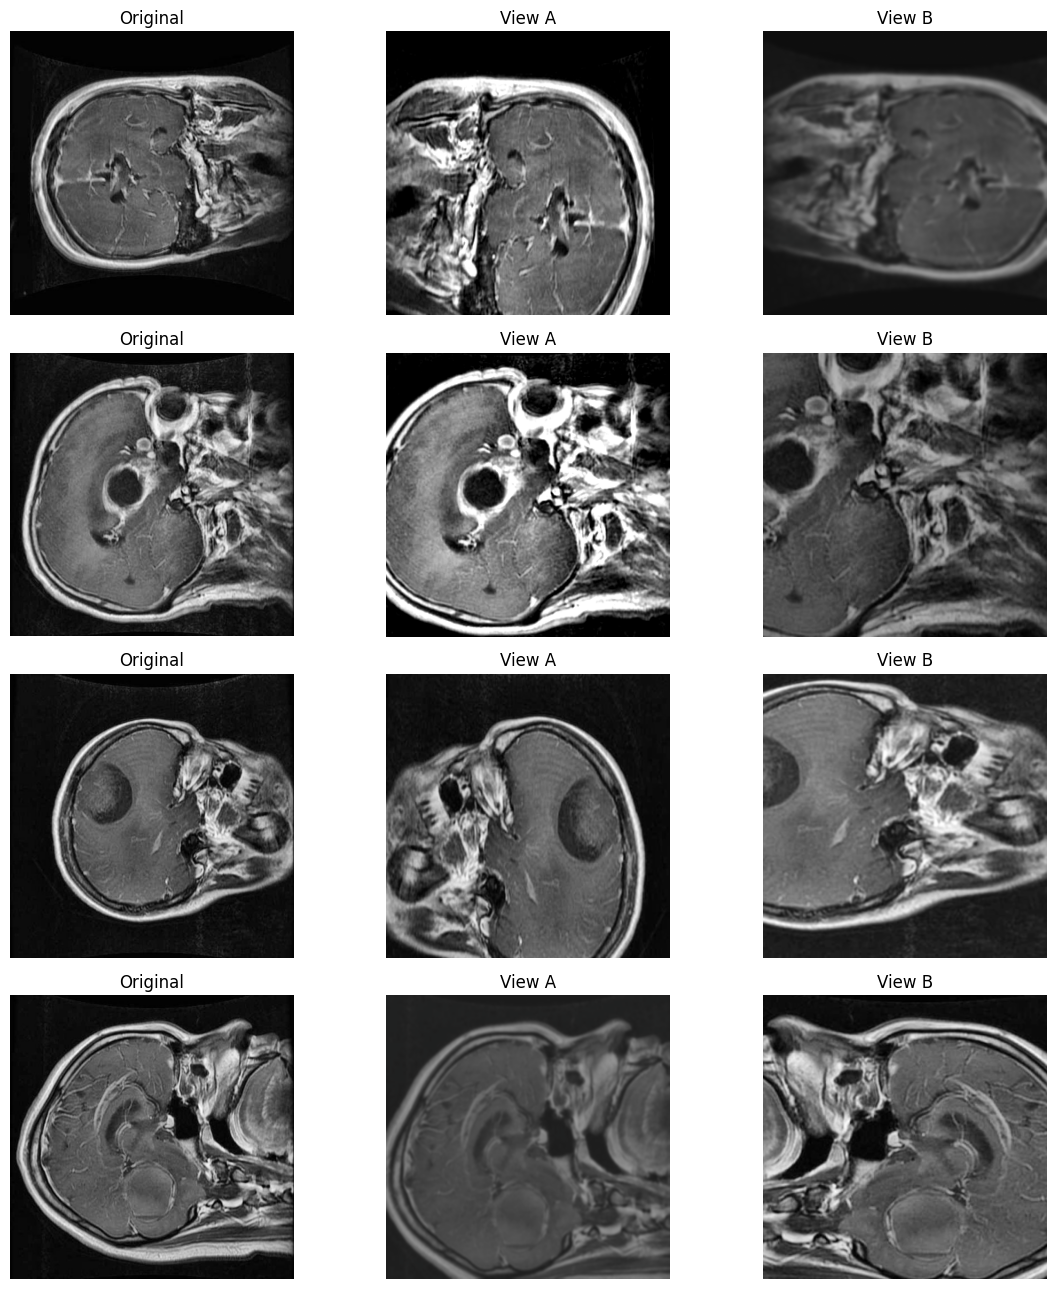

In [6]:
# Cell 6 — SimCLR datasets and augmentations
NORMALISATION_MEAN = (0.485, 0.456, 0.406)
NORMALISATION_STD = (0.229, 0.224, 0.225)

moco_transform = transforms.Compose([
    transforms.RandomResizedCrop(cfg.ssl_image_size, scale=(0.45, 1.00), antialias=True),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.40, contrast=0.40, saturation=0.35, hue=0.08)
    ], p=0.80),
    transforms.RandomGrayscale(p=0.15),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0))
    ], p=0.35),
    transforms.ToTensor(),
    transforms.Normalize(NORMALISATION_MEAN, NORMALISATION_STD),
])

evaluation_transform = transforms.Compose([
    transforms.Resize((cfg.ssl_image_size, cfg.ssl_image_size), antialias=True),
    transforms.ToTensor(),
    transforms.Normalize(NORMALISATION_MEAN, NORMALISATION_STD),
])

def denormalise(tensor):
    mean = torch.tensor(NORMALISATION_MEAN).view(3, 1, 1)
    std = torch.tensor(NORMALISATION_STD).view(3, 1, 1)
    return (tensor.detach().cpu() * std + mean).clamp(0, 1)


class MoCoImageDataset(Dataset):
    def __init__(self, image_paths, transform):
        self.image_paths = list(image_paths)
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image = Image.open(self.image_paths[index]).convert("RGB")
        return self.transform(image), self.transform(image)


class SingleViewDataset(Dataset):
    def __init__(self, frame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.loc[index]
        image = Image.open(row["image_path"]).convert("RGB")
        return evaluation_transform(image), int(row["number_of_masks"])


ssl_train_paths = manifest.loc[manifest["split"] == "train", "image_path"].tolist()
ssl_valid_paths = manifest.loc[manifest["split"] == "val", "image_path"].tolist()

ssl_train_dataset = MoCoImageDataset(ssl_train_paths, moco_transform)
ssl_valid_dataset = MoCoImageDataset(ssl_valid_paths, moco_transform)

loader_kwargs = {
    "num_workers": cfg.num_workers,
    "pin_memory": AMP_ENABLED,
}
if cfg.num_workers > 0:
    loader_kwargs["persistent_workers"] = cfg.persistent_workers
    loader_kwargs["prefetch_factor"] = cfg.prefetch_factor

ssl_train_loader = DataLoader(
    ssl_train_dataset,
    batch_size=cfg.ssl_batch_size,
    shuffle=True,
    drop_last=True,
    **loader_kwargs,
)
ssl_valid_loader = DataLoader(
    ssl_valid_dataset,
    batch_size=cfg.ssl_batch_size,
    shuffle=False,
    drop_last=False,
    **loader_kwargs,
)

fig, axes = plt.subplots(4, 3, figsize=(12, 13))
for row_index in range(min(4, len(ssl_train_dataset))):
    original = Image.open(ssl_train_paths[row_index]).convert("RGB")
    view_a, view_b = ssl_train_dataset[row_index]
    axes[row_index, 0].imshow(original)
    axes[row_index, 0].set_title("Original")
    axes[row_index, 1].imshow(denormalise(view_a).permute(1, 2, 0))
    axes[row_index, 1].set_title("View A")
    axes[row_index, 2].imshow(denormalise(view_b).permute(1, 2, 0))
    axes[row_index, 2].set_title("View B")
    for column in range(3):
        axes[row_index, column].axis("off")
plt.tight_layout()
plt.show()

In [7]:
# Cell 7 — YOLO26 graph-aware multi-scale feature extractor
yolo = YOLO(cfg.yolo_model)
segmentation_network = yolo.model.to(device)


class UltralyticsFeatureExtractor(nn.Module):
    def __init__(self, segmentation_model):
        super().__init__()
        self.segmentation_model = segmentation_model
        self.layers = segmentation_model.model
        self.detect_layer = self.layers[-1]
        self.feature_layers = self.layers[:-1]
        self.save = set(getattr(segmentation_model, "save", []))

    @staticmethod
    def route(layer, current, saved):
        source = layer.f
        if source == -1:
            return current
        if isinstance(source, int):
            return saved[source]
        return [current if index == -1 else saved[index] for index in source]

    def forward(self, images):
        saved = []
        current = images

        for layer in self.feature_layers:
            current = layer(self.route(layer, current, saved))
            saved.append(current if layer.i in self.save else None)

        sources = self.detect_layer.f
        if isinstance(sources, int):
            features = [current if sources == -1 else saved[sources]]
        else:
            features = [current if index == -1 else saved[index] for index in sources]

        if any(feature is None for feature in features):
            raise RuntimeError("Could not recover all feature maps consumed by the segmentation head.")
        return features


feature_extractor = UltralyticsFeatureExtractor(segmentation_network).to(device)

with torch.inference_mode():
    dummy = torch.zeros(2, 3, cfg.ssl_image_size, cfg.ssl_image_size, device=device)
    with amp_context():
        dummy_features = feature_extractor(dummy)

feature_shapes = [tuple(feature.shape) for feature in dummy_features]
pooled_dimension = sum(feature.shape[1] for feature in dummy_features)

print("Feature shapes:", feature_shapes)
print("Pooled dimension:", pooled_dimension)

Feature shapes: [(2, 64, 40, 40), (2, 128, 20, 20), (2, 256, 10, 10)]
Pooled dimension: 448


In [8]:
# ============================================================
# Cell 8: MoCo model, momentum encoder, and negative queue
# ============================================================
class ProjectionHead(nn.Module):
    def __init__(self, input_dimension, hidden_dimension, output_dimension):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dimension, hidden_dimension),
            nn.BatchNorm1d(hidden_dimension),
            nn.SiLU(inplace=True),
            nn.Linear(hidden_dimension, output_dimension),
        )

    def forward(self, features):
        return self.network(features)


class MoCoYOLO(nn.Module):
    """Momentum Contrast with YOLO26 multi-scale feature extractors."""

    def __init__(
        self,
        query_extractor,
        key_extractor,
        pooled_dimension,
        hidden_dimension,
        projection_dimension,
        queue_size,
        momentum,
        temperature,
    ):
        super().__init__()

        self.query_extractor = query_extractor
        self.key_extractor = key_extractor
        self.query_projector = ProjectionHead(
            pooled_dimension,
            hidden_dimension,
            projection_dimension,
        )
        self.key_projector = ProjectionHead(
            pooled_dimension,
            hidden_dimension,
            projection_dimension,
        )

        self.queue_size = int(queue_size)
        self.momentum = float(momentum)
        self.temperature = float(temperature)

        self.key_extractor.load_state_dict(self.query_extractor.state_dict())
        self.key_projector.load_state_dict(self.query_projector.state_dict())

        for parameter in self.key_extractor.parameters():
            parameter.requires_grad = False
        for parameter in self.key_projector.parameters():
            parameter.requires_grad = False

        queue = torch.randn(projection_dimension, self.queue_size)
        queue = F.normalize(queue, dim=0)
        self.register_buffer("queue", queue)
        self.register_buffer(
            "queue_pointer",
            torch.zeros(1, dtype=torch.long),
        )

    @staticmethod
    def pool_multiscale(feature_maps):
        pooled = [
            F.adaptive_avg_pool2d(feature_map, 1).flatten(1)
            for feature_map in feature_maps
        ]
        return torch.cat(pooled, dim=1)

    def encode_query(self, images):
        feature_maps = self.query_extractor(images)
        features = self.pool_multiscale(feature_maps)
        projections = self.query_projector(features)
        return features, F.normalize(projections, dim=1)

    @torch.no_grad()
    def encode_key(self, images):
        feature_maps = self.key_extractor(images)
        features = self.pool_multiscale(feature_maps)
        projections = self.key_projector(features)
        return features, F.normalize(projections, dim=1)

    @torch.no_grad()
    def momentum_update_key_encoder(self):
        for query_parameter, key_parameter in zip(
            self.query_extractor.parameters(),
            self.key_extractor.parameters(),
        ):
            key_parameter.data.mul_(self.momentum).add_(
                query_parameter.data,
                alpha=1.0 - self.momentum,
            )

        for query_parameter, key_parameter in zip(
            self.query_projector.parameters(),
            self.key_projector.parameters(),
        ):
            key_parameter.data.mul_(self.momentum).add_(
                query_parameter.data,
                alpha=1.0 - self.momentum,
            )

    @torch.no_grad()
    def dequeue_and_enqueue(self, keys):
        keys = keys.detach()
        batch_size = keys.shape[0]
        pointer = int(self.queue_pointer.item())

        if batch_size >= self.queue_size:
            self.queue.copy_(keys[-self.queue_size:].T)
            self.queue_pointer[0] = 0
            return

        end_pointer = pointer + batch_size

        if end_pointer <= self.queue_size:
            self.queue[:, pointer:end_pointer] = keys.T
        else:
            first_part = self.queue_size - pointer
            self.queue[:, pointer:] = keys[:first_part].T
            self.queue[:, :end_pointer - self.queue_size] = keys[first_part:].T

        self.queue_pointer[0] = end_pointer % self.queue_size

    def forward(self, query_images, key_images, update_queue=True):
        """
        Compute MoCo logits.

        Parameters
        ----------
        query_images : torch.Tensor
            First augmented view.
        key_images : torch.Tensor
            Second augmented view.
        update_queue : bool, default=True
            When True, update the momentum encoder and enqueue the current keys.
            Set to False for validation and smoke tests to avoid changing model state.
        """
        _, query = self.encode_query(query_images)

        with torch.no_grad():
            if update_queue:
                self.momentum_update_key_encoder()
            _, key = self.encode_key(key_images)

        positive_logits = torch.einsum(
            "nc,nc->n",
            query,
            key,
        ).unsqueeze(1)

        negative_logits = torch.einsum(
            "nc,ck->nk",
            query,
            self.queue.clone().detach(),
        )

        logits = torch.cat(
            [positive_logits, negative_logits],
            dim=1,
        )
        logits = logits / self.temperature

        labels = torch.zeros(
            logits.size(0),
            dtype=torch.long,
            device=logits.device,
        )

        if update_queue:
            self.dequeue_and_enqueue(key)

        return logits, labels, positive_logits.detach(), negative_logits.detach()


query_extractor = feature_extractor

key_network_copy = copy.deepcopy(segmentation_network).to(device)
key_extractor = UltralyticsFeatureExtractor(key_network_copy).to(device)

moco_model = MoCoYOLO(
    query_extractor=query_extractor,
    key_extractor=key_extractor,
    pooled_dimension=pooled_dimension,
    hidden_dimension=cfg.projection_hidden_dim,
    projection_dimension=cfg.projection_dim,
    queue_size=cfg.queue_size,
    momentum=cfg.momentum,
    temperature=cfg.temperature,
).to(device)

if AMP_ENABLED and cfg.use_channels_last:
    moco_model = moco_model.to(memory_format=torch.channels_last)

if cfg.use_torch_compile and hasattr(torch, "compile"):
    try:
        moco_model = torch.compile(moco_model, mode="reduce-overhead")
        print("torch.compile enabled.")
    except Exception as compile_error:
        print("torch.compile could not be enabled:", compile_error)

initial_feature_state = copy.deepcopy({
    key: value.detach().cpu()
    for key, value in query_extractor.state_dict().items()
})

ssl_optimizer = torch.optim.AdamW(
    list(moco_model.query_extractor.parameters())
    + list(moco_model.query_projector.parameters()),
    lr=cfg.ssl_learning_rate,
    weight_decay=cfg.ssl_weight_decay,
)

ssl_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    ssl_optimizer,
    T_max=max(1, cfg.ssl_epochs),
)

print("Projection dimension:", cfg.projection_dim)
print("Queue size:", cfg.queue_size)
print("Momentum coefficient:", cfg.momentum)


Projection dimension: 128
Queue size: 4096
Momentum coefficient: 0.999


In [9]:
# ============================================================
# Cell 9: Optimized MoCo training and validation
# ============================================================
import time


def move_to_device(images):
    images = images.to(device, non_blocking=AMP_ENABLED)
    if AMP_ENABLED and cfg.use_channels_last:
        return images.contiguous(memory_format=torch.channels_last)
    return images.contiguous()


def run_moco_epoch(model, loader, optimizer=None, scaler=None, description="MoCo", update_queue=True):
    training = optimizer is not None
    model.train(training)
    model.key_extractor.eval()
    model.key_projector.eval()

    total_loss = total_positive = total_negative = 0.0
    processed_batches = processed_images = 0
    start_time = time.perf_counter()

    progress = tqdm(loader, desc=description, dynamic_ncols=True, leave=False, unit="batch")
    if training:
        optimizer.zero_grad(set_to_none=True)

    for batch_index, (query_view, key_view) in enumerate(progress, start=1):
        if query_view.size(0) < 2:
            continue

        query_view = move_to_device(query_view)
        key_view = move_to_device(key_view)

        with torch.set_grad_enabled(training):
            with amp_context():
                logits, labels, positive_logits, negative_logits = model(
                    query_view, key_view, update_queue=update_queue
                )
            loss = F.cross_entropy(logits.float(), labels)
            if not torch.isfinite(loss):
                raise RuntimeError("Non-finite MoCo loss detected.")

            if training:
                scaled_loss = loss / cfg.gradient_accumulation_steps
                if AMP_ENABLED:
                    scaler.scale(scaled_loss).backward()
                else:
                    scaled_loss.backward()

                should_step = (
                    batch_index % cfg.gradient_accumulation_steps == 0
                    or batch_index == len(loader)
                )
                if should_step:
                    params = list(model.query_extractor.parameters()) + list(model.query_projector.parameters())
                    if AMP_ENABLED:
                        scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(params, max_norm=5.0)
                    if AMP_ENABLED:
                        scaler.step(optimizer)
                        scaler.update()
                    else:
                        optimizer.step()
                    optimizer.zero_grad(set_to_none=True)

        batch_size = query_view.size(0)
        total_loss += float(loss.item())
        total_positive += float(positive_logits.mean().item())
        total_negative += float(negative_logits.mean().item())
        processed_batches += 1
        processed_images += batch_size

        elapsed = max(time.perf_counter() - start_time, 1e-9)
        progress.set_postfix(
            loss=f"{total_loss/processed_batches:.4f}",
            pos=f"{total_positive/processed_batches:.3f}",
            neg=f"{total_negative/processed_batches:.3f}",
            queue=int(model.queue_pointer.item()),
            img_s=f"{processed_images/elapsed:.1f}",
            lr=f"{optimizer.param_groups[0]['lr']:.2e}" if training else "validation",
        )

    if processed_batches == 0:
        raise ValueError("No valid MoCo batches were processed.")

    elapsed = time.perf_counter() - start_time
    return {
        "loss": total_loss / processed_batches,
        "positive_similarity": total_positive / processed_batches,
        "negative_similarity": total_negative / processed_batches,
        "processed_images": processed_images,
        "elapsed_seconds": elapsed,
        "images_per_second": processed_images / max(elapsed, 1e-9),
    }


query_check, key_check = next(iter(ssl_train_loader))
query_check = move_to_device(query_check[:min(4, len(query_check))])
key_check = move_to_device(key_check[:min(4, len(key_check))])

moco_model.train()
with torch.no_grad():
    with amp_context():
        smoke_logits, smoke_labels, smoke_positive, smoke_negative = moco_model(
            query_check, key_check, update_queue=False
        )
    smoke_loss = F.cross_entropy(smoke_logits.float(), smoke_labels)

assert torch.isfinite(smoke_loss)
print(
    f"Smoke test passed | loss={smoke_loss.item():.4f} | "
    f"positive={smoke_positive.mean().item():.3f} | "
    f"negative={smoke_negative.mean().item():.3f}"
)

ssl_records = []
best_ssl_loss = float("inf")
best_ssl_state = None
total_training_start = time.perf_counter()

epoch_progress = tqdm(
    range(1, cfg.ssl_epochs + 1),
    desc="Overall MoCo progress",
    dynamic_ncols=True,
    unit="epoch",
)

for epoch in epoch_progress:
    train_result = run_moco_epoch(
        moco_model, ssl_train_loader, optimizer=ssl_optimizer, scaler=SCALER,
        description=f"Train {epoch}/{cfg.ssl_epochs}", update_queue=True,
    )
    with torch.inference_mode():
        valid_result = run_moco_epoch(
            moco_model, ssl_valid_loader, optimizer=None,
            description=f"Valid {epoch}/{cfg.ssl_epochs}", update_queue=False,
        )

    ssl_scheduler.step()
    record = {
        "epoch": epoch,
        "train_loss": train_result["loss"],
        "valid_loss": valid_result["loss"],
        "train_positive_similarity": train_result["positive_similarity"],
        "valid_positive_similarity": valid_result["positive_similarity"],
        "train_negative_similarity": train_result["negative_similarity"],
        "valid_negative_similarity": valid_result["negative_similarity"],
        "train_images_per_second": train_result["images_per_second"],
        "valid_images_per_second": valid_result["images_per_second"],
        "train_elapsed_seconds": train_result["elapsed_seconds"],
        "valid_elapsed_seconds": valid_result["elapsed_seconds"],
        "queue_pointer": int(moco_model.queue_pointer.item()),
        "learning_rate": ssl_optimizer.param_groups[0]["lr"],
    }
    ssl_records.append(record)

    if valid_result["loss"] < best_ssl_loss:
        best_ssl_loss = valid_result["loss"]
        best_ssl_state = copy.deepcopy({k: v.detach().cpu() for k, v in moco_model.state_dict().items()})

    epoch_progress.set_postfix(
        train=f"{train_result['loss']:.4f}",
        valid=f"{valid_result['loss']:.4f}",
        best=f"{best_ssl_loss:.4f}",
        queue=int(moco_model.queue_pointer.item()),
        img_s=f"{train_result['images_per_second']:.1f}",
    )

total_training_seconds = time.perf_counter() - total_training_start
if best_ssl_state is None:
    raise RuntimeError("No valid MoCo checkpoint was produced.")

moco_model.load_state_dict(best_ssl_state)
moco_model.to(device)
ssl_history = pd.DataFrame(ssl_records)
ssl_history.to_csv(SSL_OUTPUT_DIR / "moco_history.csv", index=False)

torch.save(
    {
        "config": asdict(cfg),
        "class_names": class_names,
        "moco_state_dict": moco_model.state_dict(),
        "query_feature_state_dict": moco_model.query_extractor.state_dict(),
        "best_validation_loss": best_ssl_loss,
        "total_training_seconds": total_training_seconds,
    },
    SSL_OUTPUT_DIR / "moco_yolo26_checkpoint.pt",
)

display(ssl_history.round(4))
print(f"Best validation MoCo loss: {best_ssl_loss:.4f}")
print(f"Total SSL training time: {total_training_seconds/60:.2f} minutes")
print(f"Average training throughput: {ssl_history['train_images_per_second'].mean():.1f} images/second")


Smoke test passed | loss=8.6438 | positive=-0.045 | negative=0.000


Overall MoCo progress:   0%|          | 0/5 [00:00<?, ?epoch/s]

Train 1/5:   0%|          | 0/93 [00:02<?, ?batch/s]

Valid 1/5:   0%|          | 0/27 [00:00<?, ?batch/s]

Train 2/5:   0%|          | 0/93 [00:00<?, ?batch/s]

...

Valid 4/5:   0%|          | 0/27 [00:00<?, ?batch/s]

Train 5/5:   0%|          | 0/93 [00:00<?, ?batch/s]

Valid 5/5:   0%|          | 0/27 [00:00<?, ?batch/s]

,epoch,train_loss,valid_loss,train_positive_similarity,valid_positive_similarity,train_negative_similarity,valid_negative_similarity,train_images_per_second,valid_images_per_second,train_elapsed_seconds,valid_elapsed_seconds,queue_pointer,learning_rate
0,1,6.6471,7.3096,0.9103,0.9360,0.1735,0.3379,15.2579,13.8334,97.5235,31.0119,1488,0.0003
1,2,7.6534,7.9108,0.7983,0.6386,0.4167,0.4479,16.4649,14.4904,90.3740,29.6058,2976,0.0002
2,3,8.0345,8.0712,0.3848,0.0683,0.2935,0.0173,16.5799,14.5822,89.7474,29.4194,368,0.0001
3,4,8.0420,8.0229,0.0679,0.0542,0.0104,-0.0077,17.5763,14.8112,84.6594,28.9645,1856,0.0000
4,5,8.0129,8.0132,0.0644,0.0677,0.0001,0.0033,16.9482,14.4738,87.7969,29.6398,3344,0.0000


Best validation MoCo loss: 7.3096
Total SSL training time: 10.00 minutes
Average training throughput: 16.6 images/second


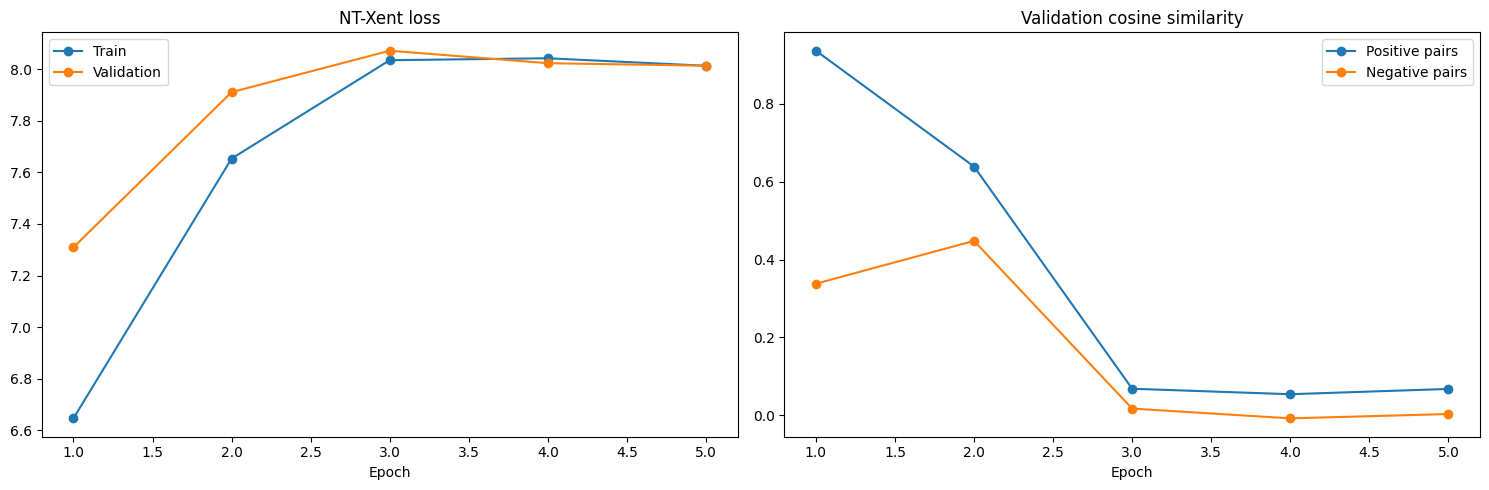

In [10]:
# Cell 10 — MoCo diagnostics
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(ssl_history["epoch"], ssl_history["train_loss"], marker="o", label="Train")
axes[0].plot(ssl_history["epoch"], ssl_history["valid_loss"], marker="o", label="Validation")
axes[0].set_title("NT-Xent loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(
    ssl_history["epoch"],
    ssl_history["valid_positive_similarity"],
    marker="o",
    label="Positive pairs",
)
axes[1].plot(
    ssl_history["epoch"],
    ssl_history["valid_negative_similarity"],
    marker="o",
    label="Negative pairs",
)
axes[1].set_title("Validation cosine similarity")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(SSL_OUTPUT_DIR / "moco_training_curves.png", dpi=220, bbox_inches="tight")
plt.show()

## 3. Stage B — YOLO26 segmentation fine-tuning

The query encoder now contains the best MoCo-pretrained YOLO26 feature weights.

Before supervised training:

1. discard the key encoder;
2. discard the query and key projection heads;
3. discard the negative queue;
4. retain the query-side YOLO26 segmentation model;
5. fine-tune it using tumor polygon labels.

The segmentation head starts from its original initialization, while the feature-producing backbone and neck start from the MoCo-pretrained state.


In [11]:
# Cell 11 — Save the SSL-initialized YOLO26 segmenter and fine-tune
ssl_initialized_path = WORKING_ROOT / "yolo26_seg_moco_initialized.pt"

# Recover the YOLO26 segmentation network updated by MoCo.
# The previous variable `ssl_segmentation_model` did not exist.
if not hasattr(query_extractor, "segmentation_model"):
    raise RuntimeError("The MoCo query extractor does not contain a segmentation model.")

# Copy to CPU without moving the active SSL model off the accelerator.
checkpoint_model = copy.deepcopy(query_extractor.segmentation_model).float().cpu()
checkpoint = {
    "model": checkpoint_model,
    "date": pd.Timestamp.utcnow().isoformat(),
    "version": ultralytics.__version__,
    "license": "AGPL-3.0",
}
torch.save(checkpoint, ssl_initialized_path)

segmenter = YOLO(str(ssl_initialized_path))
train_results = segmenter.train(
    data=str(data_yaml),
    epochs=cfg.segmentation_epochs,
    imgsz=cfg.segmentation_image_size,
    batch=cfg.segmentation_batch_size,
    workers=cfg.num_workers,
    patience=cfg.segmentation_patience,
    seed=cfg.seed,
    deterministic=True,
    pretrained=False,
    project=str(SEGMENTATION_PROJECT_DIR),
    name="moco_yolo26_seg",
    exist_ok=True,
    plots=True,
    verbose=True,
)

best_segmenter_path = Path(segmenter.trainer.best)
print("Best segmenter:", best_segmenter_path)

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/cse445_moco_yolo26/brain_tumor_yolo_seg/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/cse445_moco_yolo26/yolo26_seg_moco_initialized.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, n

In [12]:
# Cell 12 — Held-out tumor-segmentation evaluation
best_segmenter = YOLO(str(best_segmenter_path))

test_metrics = best_segmenter.val(
    data=str(data_yaml),
    split="test",
    imgsz=cfg.segmentation_image_size,
    batch=cfg.segmentation_batch_size,
    workers=cfg.num_workers,
    plots=True,
    project=str(SEGMENTATION_PROJECT_DIR),
    name="moco_yolo26_seg_test",
    exist_ok=True,
)

metrics_frame = pd.DataFrame([
    {"metric": key, "value": float(value)}
    for key, value in test_metrics.results_dict.items()
])
metrics_frame.to_csv(WORKING_ROOT / "moco_yolo26_seg_test_metrics.csv", index=False)
display(metrics_frame)

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26n-seg summary (fused): 139 layers, 2,689,469 parameters, 0 gradients, 9.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1151.3±355.8 MB/s, size: 37.0 KB)
val: Scanning /kaggle/working/cse445_moco_yolo26/brain_tumor_yolo_seg/labels/test... 215 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 215/215 1.1Kit/s 0.2s
val: New cache created: /kaggle/working/cse445_moco_yolo26/brain_tumor_yolo_seg/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 5.6it/s 4.8s
                   all        215        215       0.42      0.494      0.469      0.229      0.425      0.505      0.473      0.226
                     0        118        118      0.386      0.195      0.252     0.0995      0.384      0.195      0.253     0.0986
                     1         97         97    

,metric,value
0,metrics/precision(B),0.420466
1,metrics/recall(B),0.494365
2,metrics/mAP50(B),0.468723
3,metrics/mAP50-95(B),0.229450
4,metrics/precision(M),0.424960
5,metrics/recall(M),0.504674
6,metrics/mAP50(M),0.473375
7,metrics/mAP50-95(M),0.226081
8,fitness,0.455531


Results saved to /kaggle/working/cse445_moco_yolo26/segmentation_runs/qualitative_segmentation_predictions


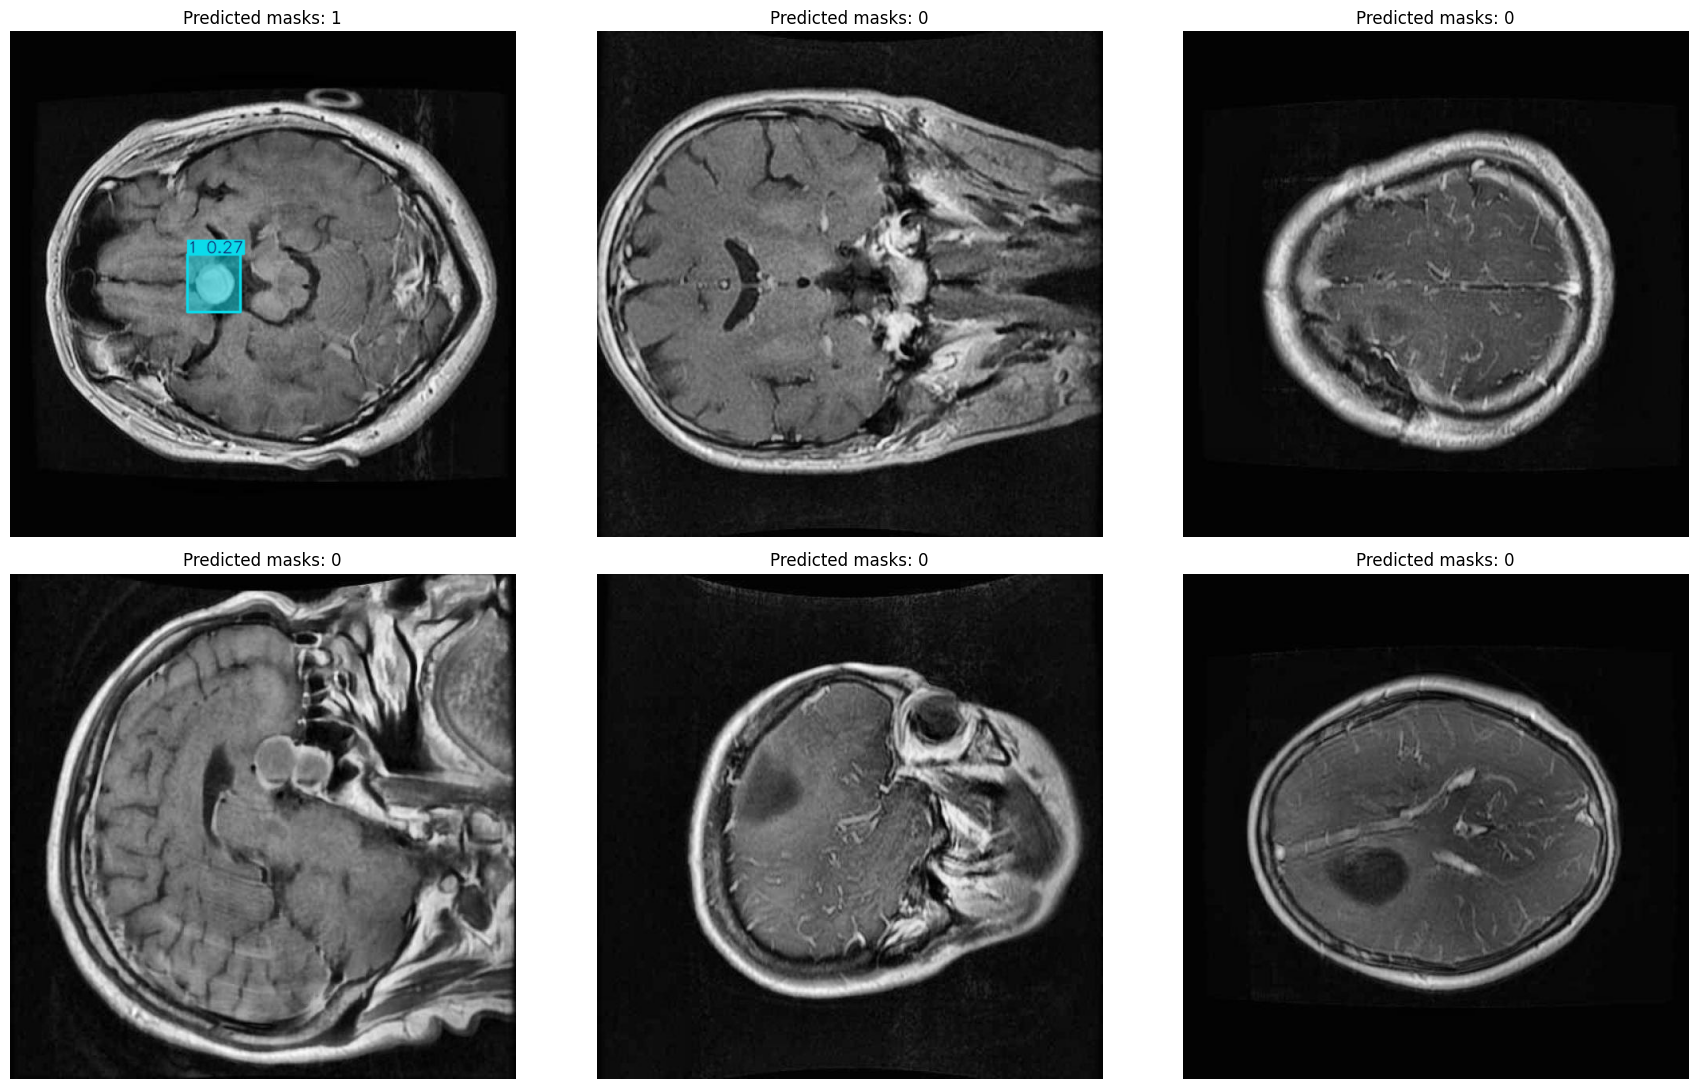

In [13]:
# Cell 13 — Qualitative tumor-mask predictions
test_images = manifest.loc[manifest["split"] == "test", "image_path"].sample(
    min(6, (manifest["split"] == "test").sum()),
    random_state=cfg.seed,
).tolist()

prediction_results = best_segmenter.predict(
    source=test_images,
    imgsz=cfg.segmentation_image_size,
    conf=0.25,
    iou=0.70,
    save=True,
    project=str(SEGMENTATION_PROJECT_DIR),
    name="qualitative_segmentation_predictions",
    exist_ok=True,
    verbose=False,
)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = np.asarray(axes).reshape(-1)

for axis, result in zip(axes, prediction_results):
    axis.imshow(result.plot()[:, :, ::-1])
    axis.set_title(f"Predicted masks: {0 if result.masks is None else len(result.masks.data)}")
    axis.axis("off")

for axis in axes[len(prediction_results):]:
    axis.axis("off")

plt.tight_layout()
plt.savefig(WORKING_ROOT / "qualitative_segmentation_predictions.png", dpi=220, bbox_inches="tight")
plt.show()

## 4. Representation analysis

The next section compares pooled YOLO26 features before and after MoCo pretraining. Samples are colored by their number of annotated tumor masks.

This visualization illustrates how the query encoder's feature space changes. t-SNE is qualitative and is not a replacement for mask mAP, Dice, or IoU.


Features:   0%|          | 0/27 [00:00<?, ?it/s]

Features:   0%|          | 0/27 [00:00<?, ?it/s]

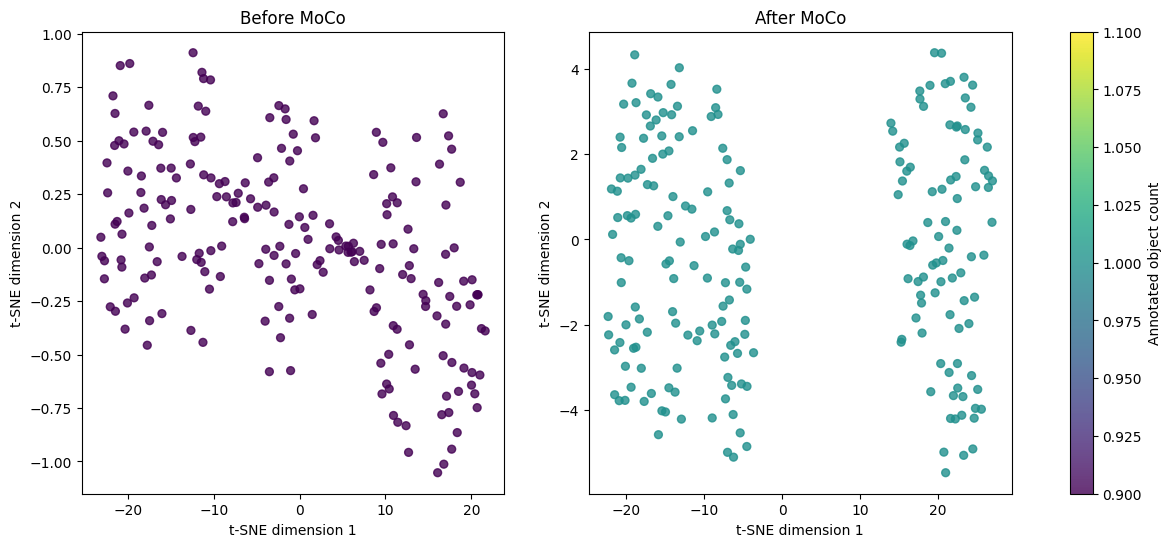

In [14]:
# Cell 14 — t-SNE before and after MoCo
feature_frame = manifest[manifest["split"] == "test"].copy()
if len(feature_frame) > cfg.tsne_max_samples:
    feature_frame = feature_frame.sample(cfg.tsne_max_samples, random_state=cfg.seed)

feature_loader = DataLoader(
    SingleViewDataset(feature_frame),
    batch_size=cfg.segmentation_batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=AMP_ENABLED,
)

def collect_features(extractor):
    extractor.eval()
    values, counts = [], []
    with torch.inference_mode():
        for images, mask_counts in tqdm(feature_loader, desc="Features", leave=False):
            images = move_to_device(images)
            with amp_context():
                maps = extractor(images)
                pooled = torch.cat([
                    F.adaptive_avg_pool2d(feature_map, 1).flatten(1)
                    for feature_map in maps
                ], dim=1)
            values.append(pooled.float().cpu().numpy())
            counts.append(mask_counts.numpy())
    return np.concatenate(values), np.concatenate(counts)

after_features, mask_counts = collect_features(moco_model.query_extractor)

ssl_feature_state = copy.deepcopy({
    key: value.detach().cpu()
    for key, value in moco_model.query_extractor.state_dict().items()
})
moco_model.query_extractor.load_state_dict(initial_feature_state)
moco_model.query_extractor.to(device)
before_features, _ = collect_features(moco_model.query_extractor)

moco_model.query_extractor.load_state_dict(ssl_feature_state)
moco_model.query_extractor.to(device)

sample_count = len(feature_frame)
perplexity = max(2, min(30, (sample_count - 1) // 3))

before_embedding = TSNE(
    n_components=2,
    perplexity=perplexity,
    init="pca",
    learning_rate="auto",
    random_state=cfg.seed,
).fit_transform(before_features)

after_embedding = TSNE(
    n_components=2,
    perplexity=perplexity,
    init="pca",
    learning_rate="auto",
    random_state=cfg.seed,
).fit_transform(after_features)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for axis, embedding, title in [
    (axes[0], before_embedding, "Before MoCo"),
    (axes[1], after_embedding, "After MoCo"),
]:
    scatter = axis.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=mask_counts,
        s=32,
        alpha=0.8,
    )
    axis.set_title(title)
    axis.set_xlabel("t-SNE dimension 1")
    axis.set_ylabel("t-SNE dimension 2")

fig.colorbar(scatter, ax=axes, label="Annotated object count")
plt.savefig(SSL_OUTPUT_DIR / "tsne_before_after_moco.png", dpi=220, bbox_inches="tight")
plt.show()

## Recommended comparative experiment

Use identical splits and compare:

| Experiment | Initialization | Label fraction |
|---|---|---:|
| A | Random YOLO26 segmentation | 10% |
| B | SimCLR-pretrained YOLO26 segmentation | 10% |
| C | MoCo-pretrained YOLO26 segmentation | 10% |
| D | Random YOLO26 segmentation | 25% |
| E | SimCLR-pretrained YOLO26 segmentation | 25% |
| F | MoCo-pretrained YOLO26 segmentation | 25% |
| G | Random YOLO26 segmentation | 100% |
| H | MoCo-pretrained YOLO26 segmentation | 100% |

Keep all downstream hyperparameters identical.

Report mask precision, recall, mAP@0.50, mAP@0.50:0.95, Dice, IoU, per-class AP, latency, and mean ± standard deviation across at least three seeds.


In [15]:
# Cell 15 — Output summary
important_paths = [
    data_yaml,
    PREPARED_ROOT / "manifest.csv",
    SSL_OUTPUT_DIR / "moco_yolo26_checkpoint.pt",
    SSL_OUTPUT_DIR / "moco_history.csv",
    SSL_OUTPUT_DIR / "moco_training_curves.png",
    SSL_OUTPUT_DIR / "tsne_before_after_moco.png",
    WORKING_ROOT / "moco_yolo26_seg_test_metrics.csv",
    WORKING_ROOT / "qualitative_segmentation_predictions.png",
    best_segmenter_path,
]

print("Pipeline completed. Important artifacts:")
for path in important_paths:
    print(" -", path)

Pipeline completed. Important artifacts:
 - /kaggle/working/cse445_moco_yolo26/brain_tumor_yolo_seg/data.yaml
 - /kaggle/working/cse445_moco_yolo26/brain_tumor_yolo_seg/manifest.csv
 - /kaggle/working/cse445_moco_yolo26/ssl_outputs/moco_yolo26_checkpoint.pt
 - /kaggle/working/cse445_moco_yolo26/ssl_outputs/moco_history.csv
 - /kaggle/working/cse445_moco_yolo26/ssl_outputs/moco_training_curves.png
 - /kaggle/working/cse445_moco_yolo26/ssl_outputs/tsne_before_after_moco.png
 - /kaggle/working/cse445_moco_yolo26/moco_yolo26_seg_test_metrics.csv
 - /kaggle/working/cse445_moco_yolo26/qualitative_segmentation_predictions.png
 - /kaggle/working/cse445_moco_yolo26/segmentation_runs/moco_yolo26_seg/weights/best.pt


## Classroom interpretation guide

1. Verify COCO-to-YOLO polygon conversion before training.
2. Confirm that query and key augmentations preserve MRI anatomy.
3. Explain why no gradient enters the key encoder.
4. Explain the exponential moving-average update.
5. Check whether positive similarities exceed average negative similarities.
6. Track the queue pointer to verify circular queue updates.
7. Compare MoCo, SimCLR, and random initialization under identical conditions.
8. Treat the short default run as a teaching demonstration.

### Common fixes

- **CUDA out of memory:** reduce batch size or image size; the queue can remain large.
- **Non-finite loss:** lower the learning rate and retain float32 cross-entropy.
- **No valid batch:** ensure at least two images are present.
- **No annotation JSON:** verify `_annotations.coco.json` in the Kaggle folders.
- **Unknown model YAML:** update Ultralytics and verify `yolo26n-seg.yaml`.
- **Weak SSL result:** increase pretraining epochs and repeat across multiple seeds.


## Optional ways to optimize the MoCo notebook further

### Recommended safe Kaggle configuration

```python
cfg.ssl_batch_size = 16
cfg.gradient_accumulation_steps = 1
cfg.queue_size = 4096
cfg.momentum = 0.999
cfg.num_workers = 2
cfg.prefetch_factor = 2
cfg.persistent_workers = True
cfg.use_channels_last = True
cfg.use_torch_compile = False
```

### Additional options

- Increase `num_workers` and `prefetch_factor` when CPU and storage are underutilized.
- Enable `torch.compile` only after the baseline runs correctly.
- Increase `queue_size` to provide more negatives, while monitoring GPU memory.
- Test momentum values between `0.99` and `0.9999`.
- Use gradient accumulation when the physical batch does not fit in memory.
- Reduce `ssl_image_size` to `224` for rapid debugging.
- Increase to `320` or `384` for stronger spatial representations.
- Test `yolo26s-seg.yaml` when more GPU memory is available.
- Cache decoded images for repeated experiments.
- Profile data loading, augmentation, transfer, model forward pass, and validation before deciding what to optimize.

The effective optimization batch size is:

$$
B_{\mathrm{effective}}
=
B_{\mathrm{physical}}
\times
N_{\mathrm{accumulation}}.
$$
